Image shape before cropping: (225, 225)
Image shape after cropping: (224, 224)


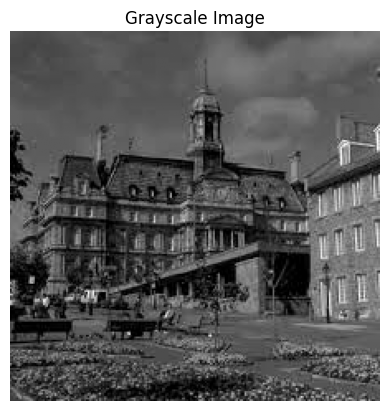

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

img_path = "Building1_img.jpg"
img = Image.open(img_path)

# Convert to grayscale
img_gray = img.convert("L")

# Convert to numpy array
I = np.array(img_gray, dtype=np.float32)
print("Image shape before cropping:", I.shape)
# Make dimensions divisible by 8 (crop)
h, w = I.shape
h_new = (h // 8) * 8
w_new = (w // 8) * 8
I = I[:h_new, :w_new]

print("Image shape after cropping:", I.shape)

plt.imshow(I, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

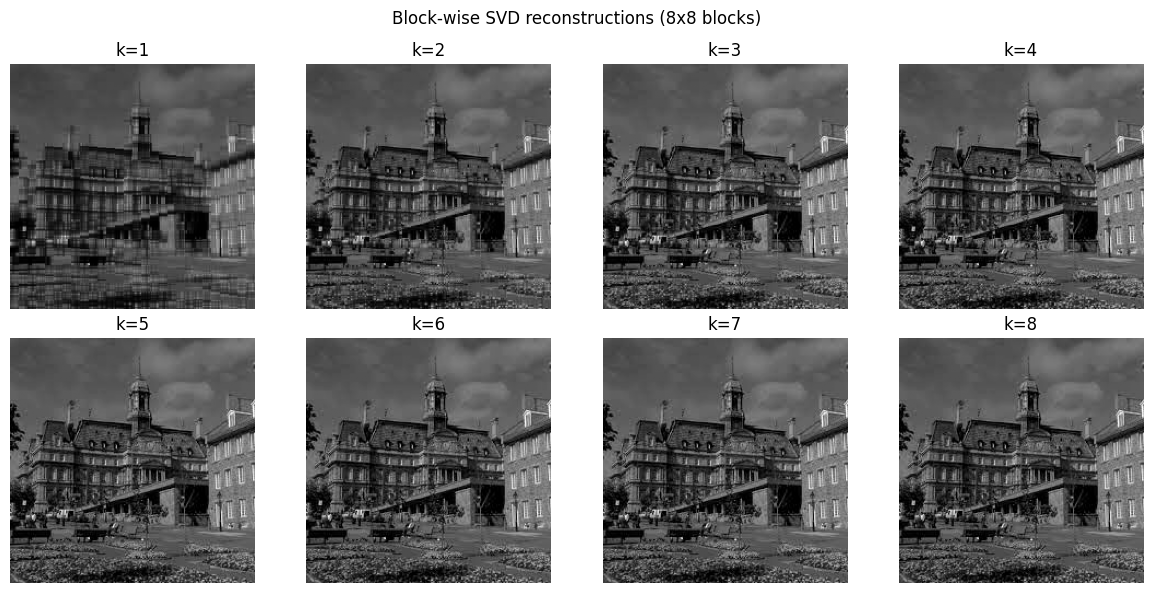

In [4]:


# --- Core function: compress a single 8x8 block using top-k SVD ---
def compress_block(block, k):
    # SVD
    U, S, Vt = np.linalg.svd(block, full_matrices=False)
    # Top-k reconstruction
    U_k = U[:, :k]
    S_k = S[:k]
    Vt_k = Vt[:k, :]
    return U_k @ np.diag(S_k) @ Vt_k

# --- Reconstruct full image from 8x8 blocks ---
def compress_image_blockwise(I, k, block_size=8):
    h, w = I.shape
    out = np.zeros_like(I)
    for i in range(0, h, block_size):
        for j in range(0, w, block_size):
            block = I[i:i+block_size, j:j+block_size]
            out[i:i+block_size, j:j+block_size] = compress_block(block, k)
    return out

# --- Metrics ---
def fro_error(I, Ik):
    return np.linalg.norm(I - Ik, ord="fro")

def compression_ratio(k, block_size=8):
    # Original per 8x8 block = 64 values
    original = block_size * block_size
    # With top-k SVD: k*(8+8+1) for 8x8 blocks
    retained = k * (block_size + block_size + 1)
    return original / retained

# Run experiment for k=1..8
ks = list(range(1, 9))
ratios = []
errors = []
recons = []

for k in ks:
    Ik = compress_image_blockwise(I, k, block_size=8)
    recons.append(Ik)
    ratios.append(compression_ratio(k, block_size=8))
    errors.append(fro_error(I, Ik))
    plt.imsave(f"recon_k{k}.png", np.clip(Ik, 0, 255), cmap="gray")

# Show a grid of reconstructions
plt.figure(figsize=(12, 6))
for idx, k in enumerate(ks):
    plt.subplot(2, 4, idx+1)
    plt.imshow(np.clip(recons[idx], 0, 255), cmap="gray")
    plt.title(f"k={k}")
    plt.axis("off")
plt.suptitle("Block-wise SVD reconstructions (8x8 blocks)")
plt.tight_layout()
plt.show()



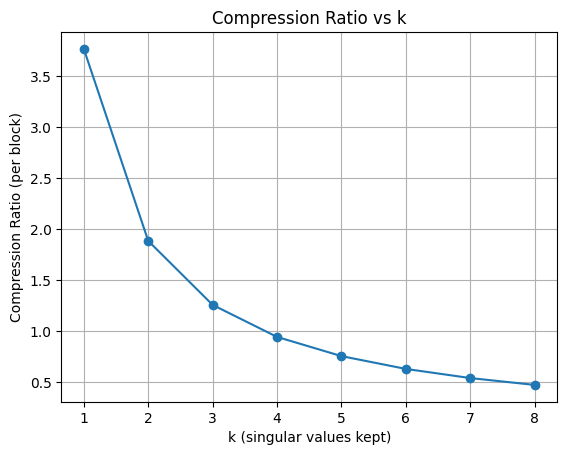

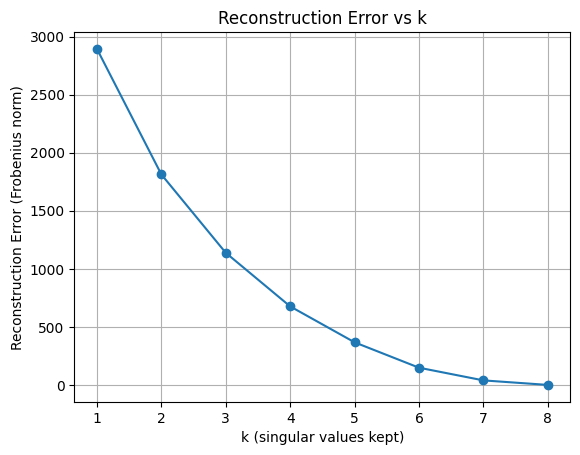

In [5]:
# Plot Compression Ratio vs k
plt.figure()
plt.plot(ks, ratios, marker="o")
plt.xlabel("k (singular values kept)")
plt.ylabel("Compression Ratio (per block)")
plt.title("Compression Ratio vs k")
plt.grid(True)
plt.show()

# Plot Reconstruction Error vs k
plt.figure()
plt.plot(ks, errors, marker="o")
plt.xlabel("k (singular values kept)")
plt.ylabel("Reconstruction Error (Frobenius norm)")
plt.title("Reconstruction Error vs k")
plt.grid(True)
plt.show()



In [8]:
# Print a small table
print("k\tCompressionRatio\tFroError")
for k, r, e in zip(ks, ratios, errors):
    print(f"{k}\t{r:.4f}\t\t\t{e:.4f}")

k	CompressionRatio	FroError
1	3.7647			2893.9016
2	1.8824			1812.6520
3	1.2549			1137.8900
4	0.9412			676.2787
5	0.7529			366.8420
6	0.6275			148.2507
7	0.5378			38.9640
8	0.4706			0.0012


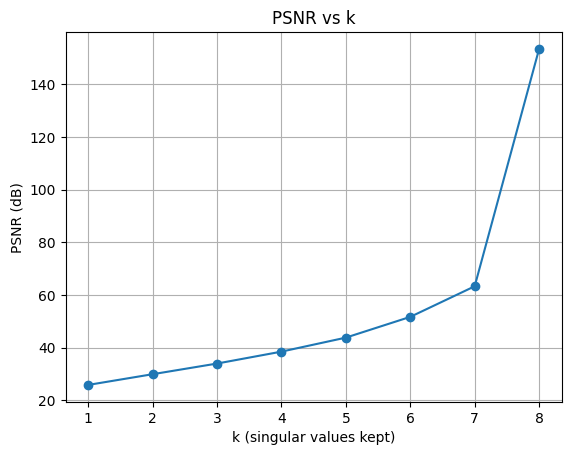

k	PSNR(dB)
1	25.9061
2	29.9695
3	34.0138
4	38.5332
5	43.8462
6	51.7158
7	63.3225
8	153.3427


In [7]:
import numpy as np
import matplotlib.pyplot as plt

def psnr(I, Ik, data_range=255.0):
    """
    PSNR in dB between original image I and reconstructed Ik.
    Assumes pixel values are in [0, data_range].
    """
    mse = np.mean((I - Ik) ** 2)
    if mse == 0:
        return float("inf")
    return 10.0 * np.log10((data_range ** 2) / mse)

# Compute PSNR for each k using your existing reconstructions (recons list)
psnrs = [psnr(I, Ik, data_range=255.0) for Ik in recons]

# Plot PSNR vs k
plt.figure()
plt.plot(ks, psnrs, marker="o")
plt.xlabel("k (singular values kept)")
plt.ylabel("PSNR (dB)")
plt.title("PSNR vs k")
plt.grid(True)
plt.savefig("psnr_vs_k.png", dpi=200, bbox_inches="tight")
plt.show()

# Print table row
print("k\tPSNR(dB)")
for k, p in zip(ks, psnrs):
    print(f"{k}\t{p:.4f}")